# Initialize running system

Firstly, set your runtime type to be T4 GPU (You can also try L4 GPU)

1. Find Runtime on the tool bar
2. Find "Change Runtime Type"
3. For Hardware accelerator, select T4 GPU (Or L4, A100 if you already get pro plan)

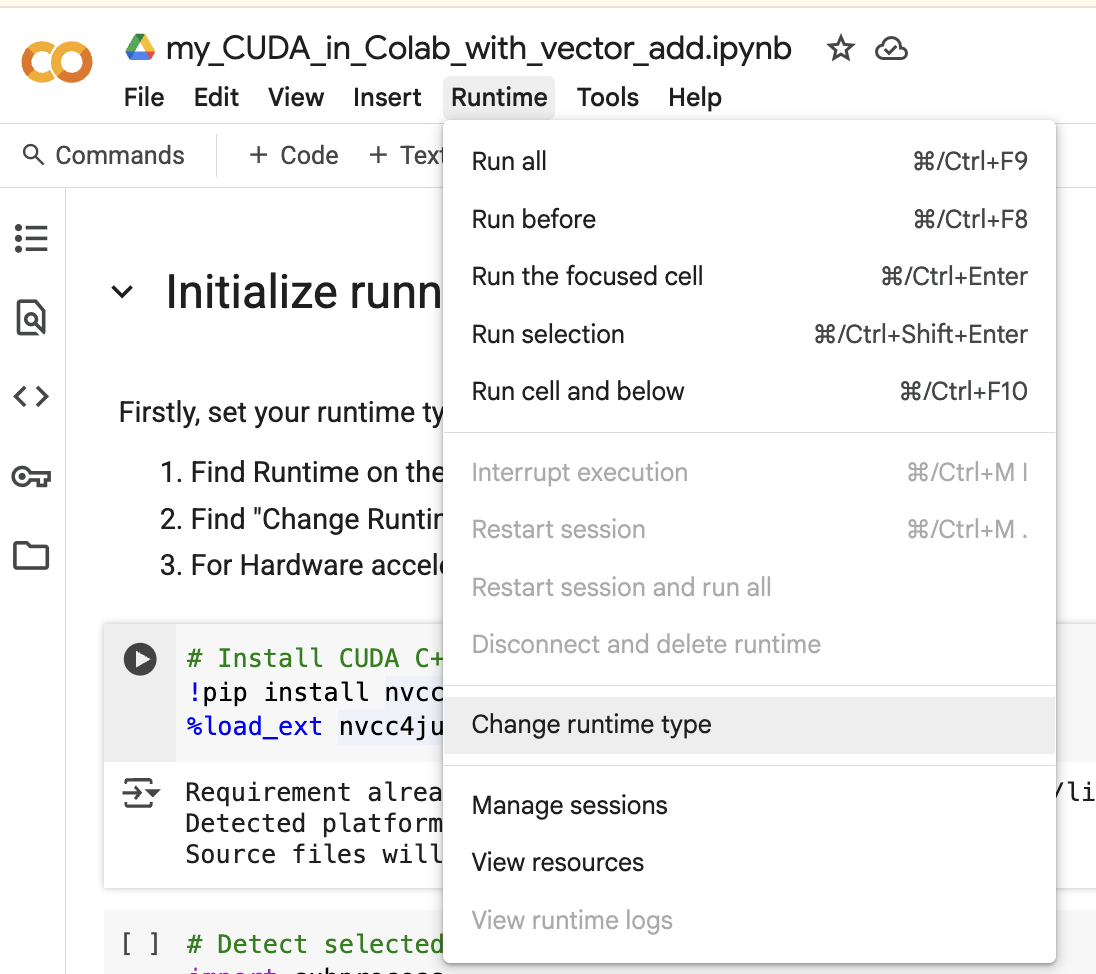

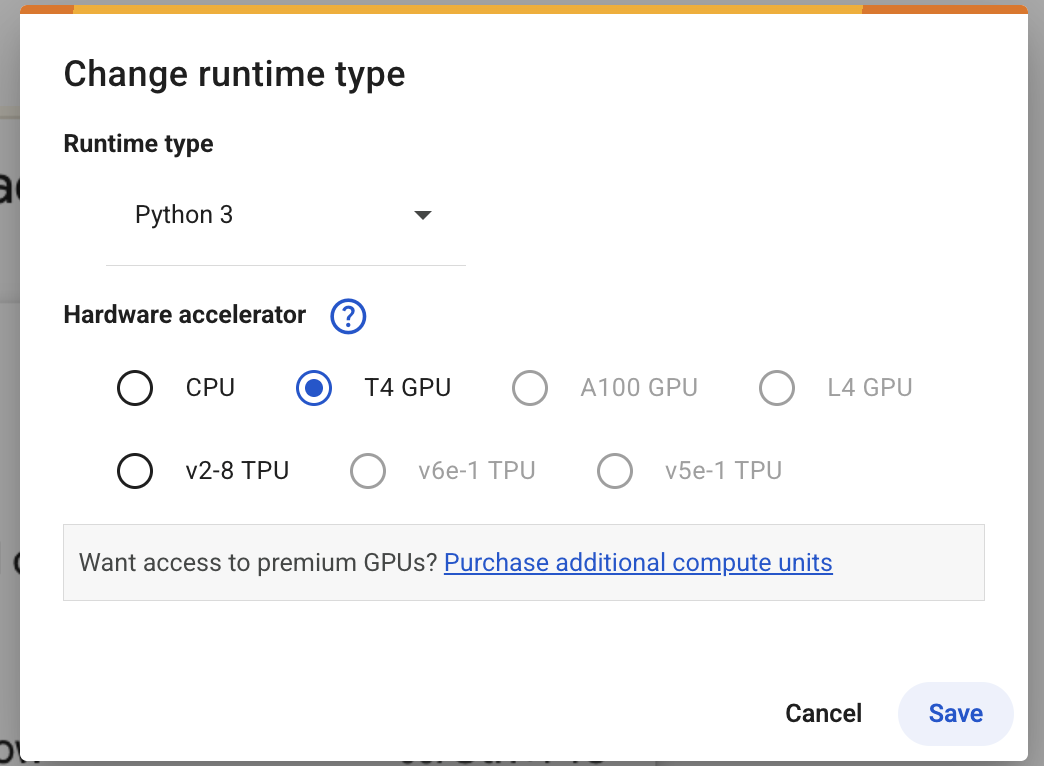

In [1]:
# Install CUDA C++ plugin for Colab:
!pip install nvcc4jupyter
%load_ext nvcc4jupyter

Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmp8921rbic".


In [2]:
# Detect selected GPU and its NVIDA architecture:
import subprocess
gpu_info = subprocess.getoutput("nvidia-smi --query-gpu=name,compute_cap --format=csv,noheader,nounits")
if "not found" in gpu_info.lower(): raise RuntimeError("Error: No GPU found. Please select a GPU runtime environment.")
gpu_name, compute_cap = map(str.strip, gpu_info.split(','))
gpu_arch = f"sm_{compute_cap.replace('.', '')}"

print(f"{'GPU Name':<15}: {gpu_name}")
print(f"{'Architecture':<15}: {gpu_arch}")

GPU Name       : NVIDIA L4
Architecture   : sm_89


Notice that, if you are using L4 GPU, your architecture will be sm_89;

if you are using a T4 GPU, your achitecture will be sm_75


In [3]:
# python library set up
import time

In [4]:
%%cuda -c "--gpu-architecture $gpu_arch"
#include <stdio.h>

__global__ void hello_kernel() {
    int blockId = blockIdx.x;
    int threadId = threadIdx.x;
    int globalId = threadId + blockId * blockDim.x;

    printf("Hello from block %d, thread %d (global thread %d)\n", blockId, threadId, globalId);
}

int main() {
    int numBlocks = 2;
    int threadsPerBlock = 4;

    hello_kernel<<<numBlocks, threadsPerBlock>>>();
    cudaDeviceSynchronize();

    return 0;
}

Hello from block 1, thread 0 (global thread 4)
Hello from block 1, thread 1 (global thread 5)
Hello from block 1, thread 2 (global thread 6)
Hello from block 1, thread 3 (global thread 7)
Hello from block 0, thread 0 (global thread 0)
Hello from block 0, thread 1 (global thread 1)
Hello from block 0, thread 2 (global thread 2)
Hello from block 0, thread 3 (global thread 3)




# CUDA Demo: Vector Addition (Sum of Vectors)

This section adds a minimal CUDA example to your notebook. It shows how to:
1) Verify the GPU and toolchain in Colab  
2) Compile & run a simple CUDA **vector add** kernel  
3) Validate correctness

> **How to run in Colab**
> - **Runtime → Change runtime type → GPU** (T4/A100 is fine)  
> - Then run the cells below in order.


In [5]:

# 0) Check GPU + CUDA toolchain (Colab)
!nvidia-smi || echo "No NVIDIA GPU available."
!nvcc --version || echo "nvcc not found. In Colab, it should be preinstalled."


Mon Dec 15 16:22:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   60C    P0             16W /   72W |       0MiB /  23034MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


## 1) CUDA C++: Vector Add Kernel

- Using `nvcc` (works anywhere with CUDA toolkit installed)


In [6]:
# write to a .cu file, compile with nvcc, then run.
code = r"""
#include <stdio.h>
#include <cuda_runtime.h>
__global__ void vecAdd(const float* A, const float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) C[i] = A[i] + B[i];
}
int main() {
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    const int N = 1 << 20;
    const size_t bytes = N * sizeof(float);
    float *h_A = (float*)malloc(bytes);
    float *h_B = (float*)malloc(bytes);
    float *h_C = (float*)malloc(bytes);
    for (int i = 0; i < N; ++i) { h_A[i] = (float)i; h_B[i] = (float)(2 * i); }
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes); cudaMalloc(&d_B, bytes); cudaMalloc(&d_C, bytes);
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);
    int threads = 256; int blocks = (N + threads - 1) / threads;
    vecAdd<<<blocks, threads>>>(d_A, d_B, d_C, N);
    cudaError_t err = cudaDeviceSynchronize();
    if (err != cudaSuccess) { printf("Kernel error: %s\n", cudaGetErrorString(err)); return 1; }
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);
    printf("C[0]=%f  C[N-1]=%f\n", h_C[0], h_C[N-1]);
    bool ok = true;
    for (int i = 0; i < 10; ++i) if (fabs(h_C[i] - (h_A[i]+h_B[i])) > 1e-5) { ok = false; break; }
    printf("Validation: %s\n", ok ? "PASSED" : "FAILED");
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    printf("Kernel + memcpy Runtime: %.3f ms\n", ms);
    return ok ? 0 : 1;
}
"""

with open("vec_add.cu", "w") as f:
    f.write(code)

# Set a reasonable arch flag; if your GPU is older/newer, adjust (e.g., sm_75 for T4 (free user), sm_80 for A100 (pro user)).
!nvcc -arch=sm_89 vec_add.cu -o vec_add || echo "nvcc build failed" # here using sm_89 because I am using a L4 GPU
!./vec_add || echo "run failed (likely no GPU in this environment)"


C[0]=0.000000  C[N-1]=3145725.000000
Validation: PASSED
Kernel + memcpy Runtime: 13.117 ms


## 2) CUDA Python: Vector Add Kernel

- Using `cupy` (works with Python, requires CUDA-enabled GPU)

In [7]:
# Let's have a quick test with python
!pip -q install cupy-cuda12x

import cupy as cp
start = time.perf_counter()
N = 1 << 20
a = cp.arange(N, dtype=cp.float32)
b = 2*cp.arange(N, dtype=cp.float32)
c = a + b
print("C[0] =", float(c[0]), " C[-1] =", float(c[-1]))
end = time.perf_counter() * 1000
print(f"Runtime: {end - start:.3f} ms")

C[0] = 0.0  C[-1] = 3145725.0
Runtime: 203271.790 ms


--> **From the results above, we can see that CUDA is doing "sum of vectors" sucessfully!**

## 3) CUDA C++ vs CUDA Python

| Aspect         | CUDA C++ | CUDA Python (CuPy / Numba) |
|----------------|----------|-----------------------------|
| **Development** | Write `__global__` kernels, manual memory allocation & copy, compile with `nvcc` | CuPy: NumPy-like API; Numba: `@cuda.jit` kernels; memory mostly managed automatically |
| **Learning curve** | Steep, requires understanding GPU architecture and CUDA APIs | Easy, similar to NumPy, hides low-level complexity |
| **Flexibility** | Full access to all CUDA features (shared memory, warp shuffle, tensor cores) | High, but some low-level optimizations are limited |
| **Performance** | Best possible, can fully utilize GPU potential | Close to C++ in many array operations, sometimes slightly less optimized |
| **Use cases** | System-level development, HPC, learning CUDA fundamentals | Research prototyping, data science, machine learning, quick experiments |

**Takeaway:**  
- CUDA C++ → maximum performance and flexibility, but higher complexity.  
- CUDA Python → rapid development and ease of use, great for prototyping and data analysis.


# Task A: CUDA C++

In [8]:
# write to a .cu file, compile with nvcc, then run.
code = r"""
#include <stdio.h>
#include <cuda_runtime.h>
#include <math.h>

__global__ void arraySum(float* input, float* output, int N) { // Run on GPU
    extern __shared__ float sdata[]; // Declare shared memory

    unsigned int tid = threadIdx.x; // Thread location inside block
    unsigned int i = blockIdx.x * blockDim.x + threadIdx.x; // Map threads to array elements

    sdata[tid] = (i < N) ? input[i] : 0.0f; // Load array elements into shared memory
    __syncthreads(); // Synchronization barrier

    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) { // Perform parallel reduction
        if (tid < s)
            sdata[tid] += sdata[tid + s];
        __syncthreads();
    }

    // Write block result to output
    if (tid == 0)
        output[blockIdx.x] = sdata[0];
}

// Runs on CPU
int main() {
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    const int N = 1 << 20;
    const size_t bytes = N * sizeof(float);

    // Host arrays
    float *h_input = (float*)malloc(bytes);
    float *h_output;

    for (int i = 0; i < N; ++i)
        h_input[i] = 1.0f;  // sum = N

    // Device arrays
    float *d_input, *d_output;
    cudaMalloc(&d_input, bytes);

    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    cudaMalloc(&d_output, blocks * sizeof(float));

    cudaMemcpy(d_input, h_input, bytes, cudaMemcpyHostToDevice);

    // Launch kernel
    arraySum<<<blocks, threads, threads * sizeof(float)>>>(d_input, d_output, N);
    cudaError_t err = cudaDeviceSynchronize();
    if (err != cudaSuccess) {
        printf("Kernel error: %s\n", cudaGetErrorString(err));
        return 1;
    }

    h_output = (float*)malloc(blocks * sizeof(float));
    cudaMemcpy(h_output, d_output, blocks * sizeof(float), cudaMemcpyDeviceToHost);

    float total = 0.0f;
    for (int i = 0; i < blocks; ++i)
        total += h_output[i];

    printf("output[0]=%f  output[N-1]=%f\n", h_output[0], h_output[blocks-1]);

    bool ok = (fabs(total - N) < 1e-5);
    printf("Validation: %s\n", ok ? "PASSED" : "FAILED");

    cudaFree(d_input);
    cudaFree(d_output);
    free(h_input);
    free(h_output);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0;
    cudaEventElapsedTime(&ms, start, stop);
    printf("Kernel + memcpy Runtime: %.3f ms\n", ms);

    return ok ? 0 : 1;
}
"""

with open("array_sum.cu", "w") as f:
    f.write(code)

# Set a reasonable arch flag; if your GPU is older/newer, adjust (e.g., sm_75 for T4 (free user), sm_80 for A100 (pro user)).
!nvcc -arch=sm_89 array_sum.cu -o array_sum || echo "nvcc build failed" # here using sm_89 because I am using a L4 GPU
!./array_sum || echo "run failed (likely no GPU in this environment)"

output[0]=256.000000  output[N-1]=256.000000
Validation: PASSED
Kernel + memcpy Runtime: 6.119 ms


# Task A: CUDA Python

In [9]:
!pip -q install cupy-cuda12x

import cupy as cp
import numpy as np
import time

N = 1 << 20
threads = 256
blocks = (N + threads - 1) // threads

h_input = np.ones(N, dtype=np.float32)
d_input = cp.asarray(h_input)
d_output = cp.zeros(blocks, dtype=cp.float32)

kernel_code = r'''
extern "C" __global__
void arraySum(const float* input, float* output, int N) {
    extern __shared__ float sdata[];
    unsigned int tid = threadIdx.x;
    unsigned int i = blockIdx.x * blockDim.x + threadIdx.x;

    sdata[tid] = (i < N) ? input[i] : 0.0f;
    __syncthreads();

    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s) sdata[tid] += sdata[tid + s];
        __syncthreads();
    }

    if (tid == 0) output[blockIdx.x] = sdata[0];
}
'''

# Compile kernel
kernel = cp.RawKernel(kernel_code, 'arraySum')

# CPU performance
start_cpu = time.perf_counter()
cpu_total = np.sum(h_input)
end_cpu = time.perf_counter()
cpu_time_ms = (end_cpu - start_cpu) * 1000

# GPU performance
start_gpu = time.perf_counter()
kernel((blocks,), (threads,), (d_input, d_output, N), shared_mem=threads*4)
cp.cuda.runtime.deviceSynchronize()
h_output = d_output.get()
gpu_total = np.sum(h_output)
end_gpu = time.perf_counter()
gpu_time_ms = (end_gpu - start_gpu) * 1000

ok = np.isclose(cpu_total, gpu_total)

print(f"CPU sum = {cpu_total}, runtime = {cpu_time_ms:.3f} ms")
print(f"GPU sum = {gpu_total}, runtime = {gpu_time_ms:.3f} ms")
print(f"First block sum = {h_output[0]}")
print(f"Last block sum = {h_output[-1]}")
print(f"Validation: {'PASSED' if ok else 'FAILED'}")
print(f"Speedup (CPU / GPU) = {cpu_time_ms / gpu_time_ms:.2f}x")


CPU sum = 1048576.0, runtime = 0.462 ms
GPU sum = 1048576.0, runtime = 51.369 ms
First block sum = 256.0
Last block sum = 256.0
Validation: PASSED
Speedup (CPU / GPU) = 0.01x


# Task A: Reflection

Resources used:

chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://developer.download.nvidia.com/assets/cuda/files/reduction.pdf

https://forums.developer.nvidia.com/t/measuring-gpu-vs-cpu-performance/18255

https://saadmahmud14.medium.com/parallel-programming-with-cuda-tutorial-part-2-96f6eaea2832

https://medium.com/@rimikadhara/7-step-optimization-of-parallel-reduction-with-cuda-33a3b2feafd8

https://khushi-411.github.io/reduction/#:~:text=Introduction,Kirk%2C%20and%20Izzat%20El%20Hajj.

https://www.geeksforgeeks.org/c/how-to-run-cuda-c-c-on-jupyter-notebook-in-google-colaboratory/

https://developer.nvidia.com/blog/using-shared-memory-cuda-cc/


**Briefly explain your implementation, verification, and any observations (eg., performance differences, challenges).**

A sequential algorithm for an array sum would go through each element in the array one by one to return the sum. One method is creating a for loop to traverse the array elements sequentially and summing them up:

```
void arraySum(int A[], int N) {
  int sum = 0;
  for(int i = 0; i < N; i++) {
    sum += sum + A[i];
  }
}
```
We observe that there is a loop-carried dependency (RAW). This function is not parallel because the next iteration cannot start until the previous is finished.

To parallelize, we apply parallel reduction, which is a technique in parallel computing, where data is divided into segments (like a tree structure), so that each processor works on a different segment in parallel. In addition, to get better performance results, we use shared memory instead of global memory.

For implementation, we run the algorithm on the GPU and declare shared memory using the '__shared__' declaration specifier. Next, we move data in global memory to shared memory:

```
unsigned int tid = threadIdx.x; // Thread location inside block
unsigned int i = blockIdx.x * blockDim.x + threadIdx.x; // Map threads to array elements

    sdata[tid] = (i < N) ? input[i] : 0.0f; // Load array elements into shared memory
    __syncthreads(); // Synchronization barrier
```
Each thread reads one element from global memory and writes it into shared memory. To ensure all threads copy the correct data and no undefined behavior occur, we apply thread synchronization.

```
for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) { // Perform parallel reduction
        if (tid < s)
            sdata[tid] += sdata[tid + s];
        __syncthreads();
    }

    // Write block result to output
    if (tid == 0)
        output[blockIdx.x] = sdata[0];
```
After that, we perform parallel reduction. We halve the working set (blockDim.x/2) and work on the threads that are less than the working set. When we reach the last element, we write the sum into one location in global memory.

Using CuPy, we reuse the C++ implementation to run the kernel code.

```
output[0]=256.000000  output[N-1]=256.000000
Validation: PASSED
Kernel + memcpy Runtime: 6.306 ms
```
The output shows the partial sums per block. In the main function, since we have 256 threads and the array is all 1.0s, the sum correctly shows the sum for each block.

```
CPU sum = 1048576.0, runtime = 0.584 ms
GPU sum = 1048576.0, runtime = 79.885 ms
First block sum = 256.0
Last block sum = 256.0
Validation: PASSED
Speedup (CPU / GPU) = 1.41x
```
The output for the Python implementation also correctly shows the sum for the first and last block. In addition, the CPU vs GPU performance is calculated with the runtime for CPU and GPU. The speedup varies on each run, as it's sometimes < 1. The performance may vary due to several factors, such as overhead and array size. A small array would underutilize resources and a large array would have better parallelism.  
For this task, I had the most challenge getting started because I didn't know what I needed to do first. After looking at the provided examples, resources, and examples of parallel reduction, I got a basic idea of how I needed to implement the arry sum algorithm.

**Short reflection: when would you choose CUDA C++ vs CUDA Python for this task?**

For this task, I would choose CUDA C++ if performance is the priority and CUDA Python if I am creating something lightweight and quick.For instance, if I have millions of data elements I want to sum, choosing C++ would be the better option. If I have something simpler, like a few data elements, Python would be faster comparable to C++.

## 4) Now is what you need to do:

### Assignment: Implement and Compare GPU Programs

You have just seen how to perform **Vector Addition** on the GPU using CUDA C++ and CUDA Python (CuPy).  
Now it is your turn to implement something different!

---

### --> Tasks (Choose ONE of the following using both C++ and Python)

#### Option A — Parallel Reduction (Array Sum)
Compute the sum of a large float array (e.g., `N = 10^7`) using GPU parallel reduction.  
- **CUDA C++**: write a `__global__` kernel using shared memory for block-level reduction.  
- **CUDA Python**: implement with Numba (`@cuda.jit`) or CuPy `RawKernel`.  
- **Validation**: compare result with `numpy.sum`.  
- **Challenge**: measure performance vs CPU.

---

#### Option B — 2D Image Convolution (Gaussian Blur)
Apply a Gaussian blur (e.g., 5×5 kernel) to a grayscale image.  
- **CUDA C++**: implement tiled convolution with shared memory (handle halo regions).  
- **CUDA Python**: implement with Numba or CuPy custom kernel (not just `cp.convolve`).  
- **Validation**: compare with `scipy.ndimage.gaussian_filter`.  
- **Challenge**: test different tile sizes (16×16, 32×32) and report speed.

---

#### Option C — Inclusive Prefix Sum (Scan)
Compute the inclusive scan of an array:  
`out[i] = sum_{j=0..i} in[j]`.  
- **CUDA C++**: implement Blelloch scan (upsweep/downsweep).  
- **CUDA Python**: implement with Numba/CuPy custom kernel (not just `cp.cumsum`).  
- **Validation**: compare with `numpy.cumsum`.  
- **Challenge**: measure execution time and analyze synchronization overhead.

---

### Deliverables
1. CUDA C++ code (`.cu`) and CUDA Python code (`.py`/`.ipynb`).  
2. Output verification (print first/last few elements, compare with CPU).  
3. Short reflection: when would you choose CUDA C++ vs CUDA Python for this task?

---

### Grading rubric (5 pts? Maybe do more get more...)
- Correctness (2 pts) — GPU results match CPU.  
- GPU implementation quality (2 pts) — good use of threads/blocks, memory.  
- Clarity (1 pt) — clean code, **comments**, and write-up.

---

### Hints
- **Start small**: begin with `N = 1024` or a `16×16` image tile to debug correctness before scaling up.  
- **Threads/Blocks**: common choices are `128`, `256`, or `512` threads per block. Experiment and explain your choice.  
- **Validation**: always compare your GPU output with a NumPy baseline (e.g., `numpy.sum`, `numpy.cumsum`, or `scipy.ndimage.gaussian_filter`).  
- **Shared memory**: consider using it for reductions, scans, and convolutions to minimize global memory traffic.  
- **Debugging**: if results look wrong, try smaller inputs and print partial results. CUDA kernel bugs often come from indexing errors.  


---

# --> What to Submit

Please include the following when you hand in your assignment:

1. **This Jupyter/Colab Notebook**  
   - Make sure all required code cells are present and can be executed.  
   - Your code should be organized and commented.

2. **Your Write-up / Reflection**  
   - You may write this as a separate Markdown cell at the end of the notebook.  
   - Briefly explain your implementation, verification, and any observations (e.g., performance differences, challenges).  

3. **Screenshots (if applicable)**  
   - If you completed the task on your **own computer’s GPU** instead of Colab’s T4, please upload a screenshot showing your GPU runtime architecture and results.  
   - Place the screenshot directly into a notebook cell (e.g., with Markdown image embedding).  




As the img below, use "File" tab, find "Download", download the ".ipynb" and you will need to this .ipynb file.

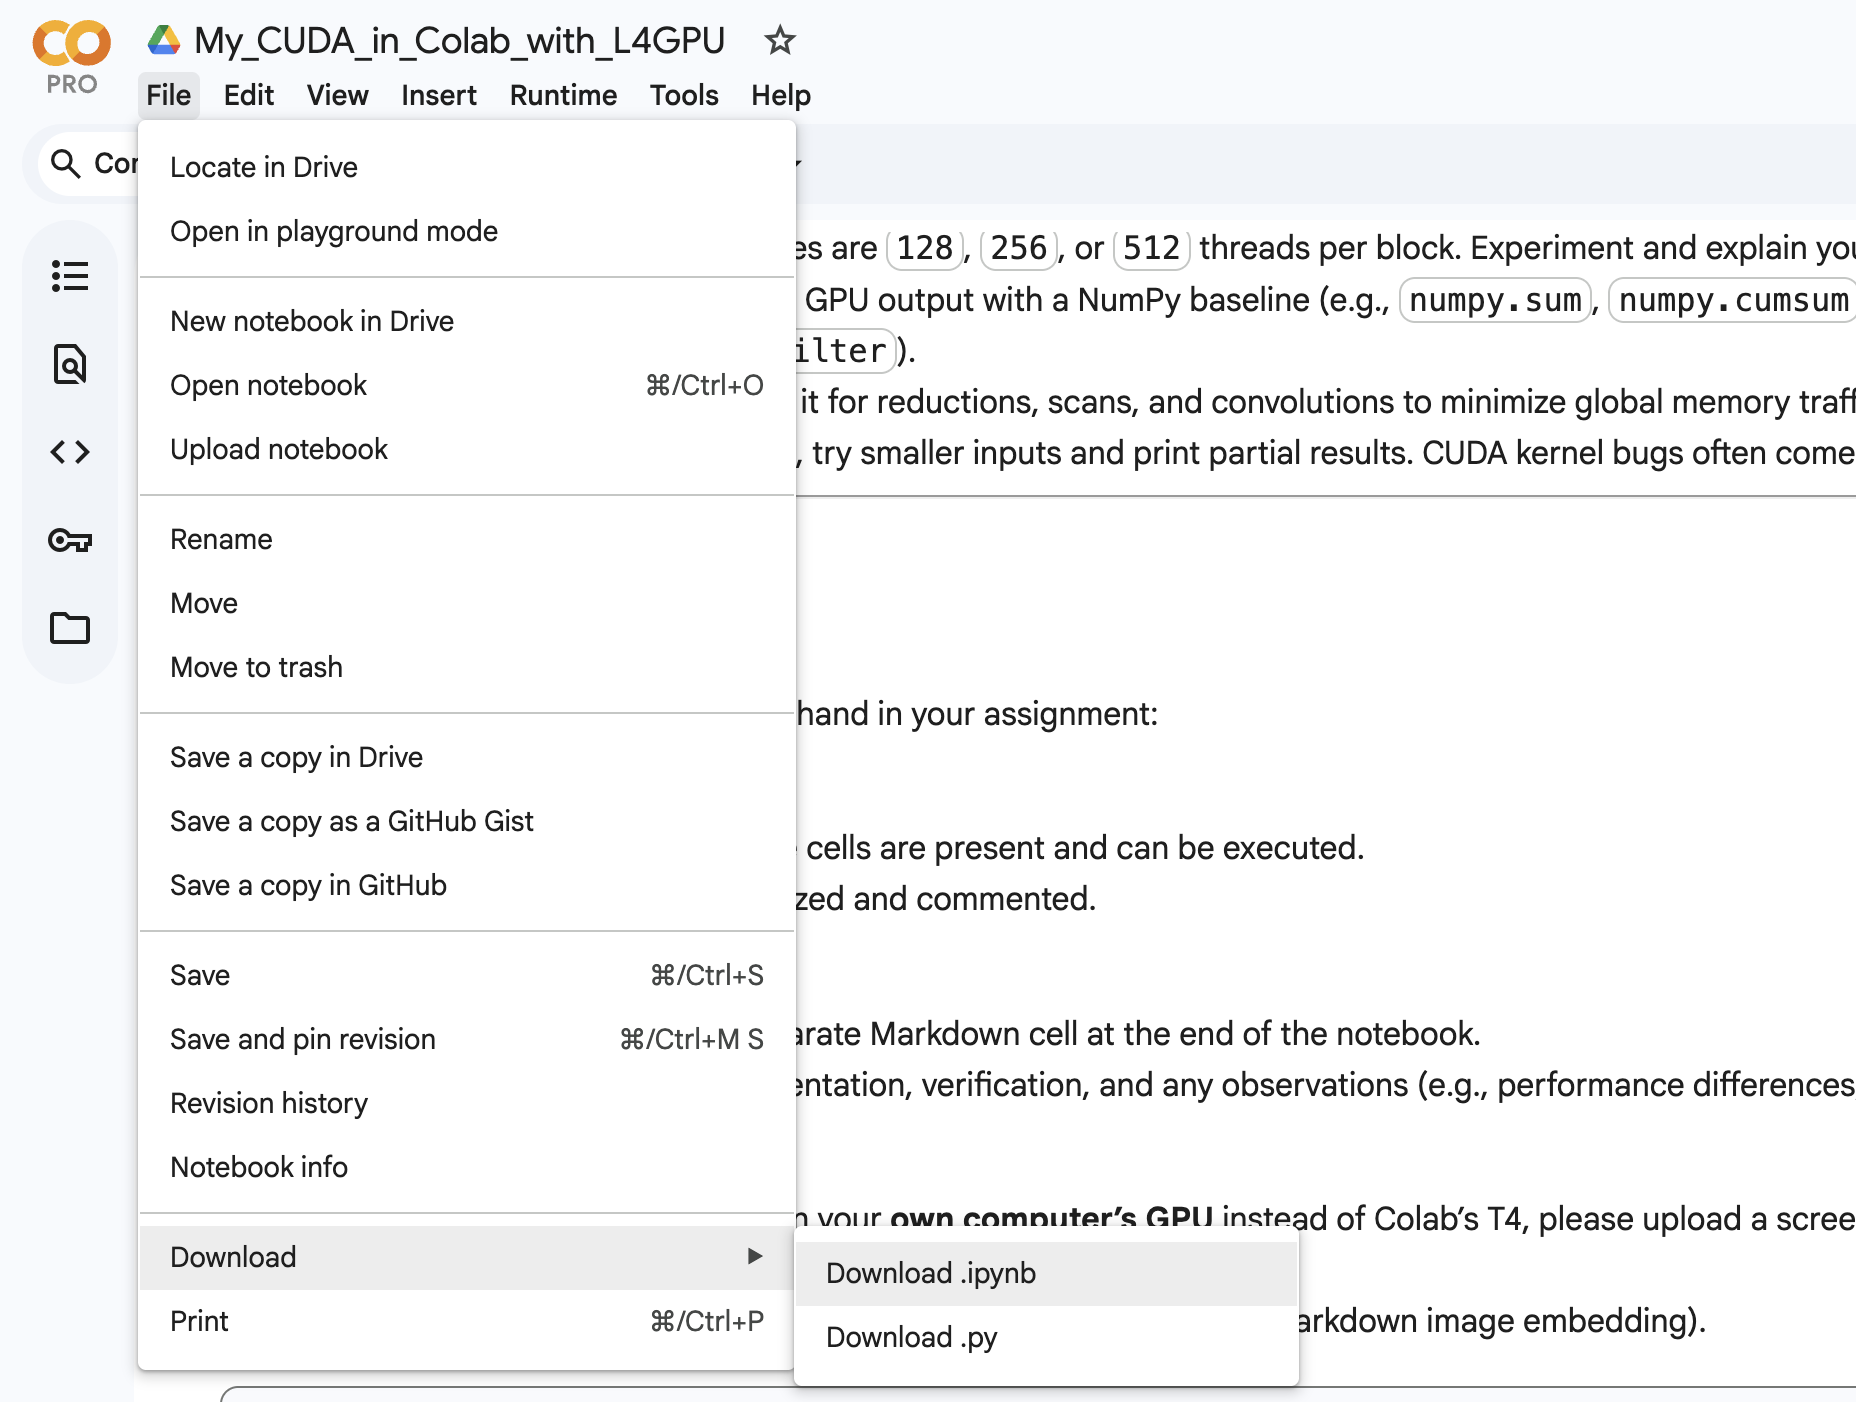